# Full spread-metric analysis: all seeds, all epsilon_ff, both Sigma_cloud

- Discovers every numeric seed directory present for each Sigma/e_ff family.
- Uses fixed six-bin geometry from the 1 Myr isochrone:
    HR: 3000,3100,...,3600 K
    CMDs: six equal-width COLOR bins between the 1 Myr colors at 3000/3600 K.
- A star is eligible only when 3000 <= Teff <= 3600 K; eligible CMD stars
  enter bins by ACTUAL color only.
- Builds a matched instantaneous control for EVERY (Sigma,e_ff,seed).
- Saves per-realization summary/bin/accounting tables and aggregate tables.
- Requested plots:
    (1) all e_ff curves separately for each Sigma, with mean +/- 1 sample-SD seed bands;
    (2) both Sigma families on one plot for each diagram.
- No CMD time-evolution multipanels.

In [1]:
from __future__ import annotations

import contextlib
import io
import json
import math
import os
import shutil
import sys
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Column, Table

from spisea import atmospheres, reddening, synthetic
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/home/wyz5rge/synthetic-cmd-dev/cmd_generator')
import interpolator  # noqa: E402

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


## Configuration

In [2]:
UPDATED_MERGED_ROOT = Path(
    '/home/wyz5rge/SPISEA/evolution/merged/baraffe_pisa_ekstrom_parsec/'
)
SIMULATION_BASE = Path(
    '/standard/Tan_JC/backup_protoclusters/multiples/M3000new'
)

# The resolver tries these names in order. Add another spelling here if your
# Sigma=1 directory uses a different name.
SIGMA_DIR_CANDIDATES = {
    0.1: ['sigma0p1'],
    1.0: ['sigma1', 'sigma1p0', 'sigma1p00'],
}
EFF_CONFIG = {
    0.01: 'sfe_ff001',
    0.03: 'sfe_ff003',
    0.10: 'sfe_ff010',
    0.30: 'sfe_ff030',
    1.00: 'sfe_ff100',
}
FIDUCIAL_SUBDIR = 'fiducial'

OUTPUT_DIR = Path.cwd() / 'all_seeds_all_sigma_all_eff_spread_std_outputs'
CACHE_DIR = Path.cwd() / 'all_seeds_all_sigma_all_eff_analysis_cache'
ISO_CACHE_DIR = Path.cwd() / 'iso_cache'

RESET_ISO_CACHE = False
RECOMPUTE_REALIZATIONS = False
RECOMPUTE_COMBINED_TABLES = False
SAVE_FIGURES = True
SHOW_FIGURES = True

USE_ROTATING_MERGED = False
AKS = 0.0
DISTANCE_PC = 410.0
METALLICITY = 0.0
ATM_FUNC = atmospheres.get_BTSettl_2015_atmosphere
RED_LAW = reddening.RedLawHosek18b()

ISO_AGES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
ISO_LOG_AGES = np.log10(ISO_AGES_MYR * 1e6)
ANALYSIS_TIMES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)

TEFF_MIN_K, TEFF_MAX_K = 3000.0, 3600.0
N_BINS = 6
HR_TEFF_BIN_EDGES_K = np.linspace(TEFF_MIN_K, TEFF_MAX_K, N_BINS + 1)
REFERENCE_BIN_AGE_MYR = 1.0
MIN_STARS_PER_BIN = 8
NORMALIZATION_MIN_BASELINE = 1e-8
CLIP_YOUNG_TO_GRID = True
N_PRIMORDIAL_COMPONENTS = 150
L_SUN_WATTS = 3.846e26

FILTER_OBSMODES = {
    'F070W': 'jwst,F070W',
    'F182M': 'jwst,F182M',
    'F200W': 'jwst,F200W',
    'F555W': 'wfc3,uvis1,f555w',
    'F814W': 'wfc3,uvis1,f814w',
}
ALL_FILTERS = list(FILTER_OBSMODES.values())

In [3]:
@dataclass(frozen=True)
class Diagram:
    key: str
    title: str
    xlabel: str
    ylabel: str
    kind: str
    blue: str | None = None
    red: str | None = None
    y_filter: str | None = None
    invert_x: bool = False
    invert_y: bool = False


DIAGRAMS = [
    Diagram('hr', r'$\log(L/L_\odot)$ vs. $T_{\rm eff}$',
            r'$T_{\rm eff}$ [K]', r'$\log(L/L_\odot)$', 'hr', invert_x=True),
    Diagram('f070w_f200w', 'F070W - F200W vs. F200W',
            'F070W - F200W', 'F200W', 'cmd',
            'F070W', 'F200W', 'F200W', invert_y=True),
    Diagram('f182m_f200w', 'F182M - F200W vs. F200W',
            'F182M - F200W', 'F200W', 'cmd',
            'F182M', 'F200W', 'F200W', invert_y=True),
    Diagram('hst_f555w_f814w', 'HST F555W - F814W vs. F814W',
            'F555W - F814W', 'F814W', 'cmd',
            'F555W', 'F814W', 'F814W', invert_y=True),
]

## General helpers / discovery

In [4]:
def show_table(df, n=None):
    df2 = df.head(n) if n is not None else df
    try:
        from IPython.display import display
        display(df2)
    except Exception:
        print(df2.to_string(index=False))


def prepare_dirs():
    if RESET_ISO_CACHE and ISO_CACHE_DIR.exists():
        shutil.rmtree(ISO_CACHE_DIR)
    for p in (OUTPUT_DIR, CACHE_DIR, ISO_CACHE_DIR):
        p.mkdir(parents=True, exist_ok=True)


def finish_figure(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / filename, dpi=220, bbox_inches='tight')
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def normalize_name(value):
    return ''.join(ch.lower() for ch in str(value) if ch.isalnum())


def sigma_tag(x):
    return f'sigma_{x:g}'.replace('.', 'p')


def eff_tag(x):
    return f'eff_{x:g}'.replace('.', 'p')


def resolve_sigma_root(sigma):
    for dirname in SIGMA_DIR_CANDIDATES[sigma]:
        p = SIMULATION_BASE / dirname / FIDUCIAL_SUBDIR
        if p.is_dir():
            return p
    existing = sorted(p.name for p in SIMULATION_BASE.iterdir() if p.is_dir())
    raise FileNotFoundError(
        f'Cannot resolve Sigma={sigma:g}. Tried {SIGMA_DIR_CANDIDATES[sigma]}. '
        f'Existing under {SIMULATION_BASE}: {existing}'
    )


def discover_simulations():
    rows, mapping = [], {}
    for sigma in SIGMA_DIR_CANDIDATES:
        root = resolve_sigma_root(sigma)
        for eff, eff_dirname in EFF_CONFIG.items():
            eff_dir = root / eff_dirname
            if not eff_dir.is_dir():
                print(f'WARNING missing: Sigma={sigma:g}, eff={eff:g}: {eff_dir}')
                continue
            seeds = sorted(
                [p.name for p in eff_dir.iterdir() if p.is_dir() and p.name.isdigit()],
                key=lambda x: int(x),
            )
            for seed in seeds:
                path = eff_dir / seed
                mapping[(float(sigma), float(eff), seed)] = path
                rows.append({
                    'sigma_cloud_g_cm2': float(sigma),
                    'epsilon_ff': float(eff),
                    'seed': seed,
                    'simulation_path': str(path),
                })
    inventory = pd.DataFrame(rows)
    if inventory.empty:
        raise RuntimeError('No simulations discovered.')
    return mapping, inventory


prepare_dirs()
SIMULATION_PATHS, df_inventory = discover_simulations()
df_inventory.to_csv(OUTPUT_DIR / 'simulation_inventory.csv', index=False)
print(f'Discovered {len(df_inventory)} simulations')
show_table(
    df_inventory.groupby(['sigma_cloud_g_cm2', 'epsilon_ff'], as_index=False)
    .agg(n_seeds=('seed', 'nunique'))
)

Discovered 200 simulations


,sigma_cloud_g_cm2,epsilon_ff,n_seeds
0,0.1,0.01,20
1,0.1,0.03,20
2,0.1,0.10,20
3,0.1,0.30,20
4,0.1,1.00,20
5,1.0,0.01,20
6,1.0,0.03,20
7,1.0,0.10,20
8,1.0,0.30,20
9,1.0,1.00,20


## Evolution model / isochrones

In [5]:
class MergedBaraffePisaEkstromParsecDAT:
    def __init__(self, root_dir: Path | str, rot=False):
        self.root_dir = Path(root_dir).expanduser().resolve()
        self.rot = bool(rot)
        self.model_dir = str(self.root_dir)
        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list = []
        self.grid_dir = self.root_dir / ('z015_rot' if rot else 'z015_norot')
        if not self.grid_dir.is_dir():
            raise FileNotFoundError(self.grid_dir)
        self.age_file_map = {}
        for p in sorted(self.grid_dir.glob('iso_*.dat')):
            try:
                age = float(p.stem.split('_')[1])
            except (IndexError, ValueError):
                continue
            self.age_file_map[round(age, 2)] = p
        if not self.age_file_map:
            raise FileNotFoundError(f'No iso_*.dat in {self.grid_dir}')
        self.age_list = np.array(sorted(self.age_file_map), float)

    def isochrone(self, age=1e6, metallicity=0.0):
        requested = math.log10(age)
        if requested < self.age_list[0] or requested > self.age_list[-1]:
            raise ValueError(f'logAge {requested:.4f} outside grid')
        selected = float(self.age_list[np.argmin(np.abs(self.age_list - requested))])
        path = self.age_file_map[round(selected, 2)]
        dtype = [
            ('mass', 'f8'), ('logT', 'f8'), ('logL', 'f8'), ('logg', 'f8'),
            ('logT_WR', 'f8'), ('mass_current', 'f8'), ('phase', 'i4'),
            ('model_ref', 'U32'),
        ]
        data = np.genfromtxt(path, comments='#', dtype=dtype, encoding='utf-8')
        iso = Table(np.atleast_1d(data))
        iso.add_column(Column(
            ~np.isclose(np.asarray(iso['logT'], float),
                        np.asarray(iso['logT_WR'], float),
                        rtol=0.0, atol=1e-8),
            name='isWR',
        ))
        iso.meta.update({
            'log_age': selected, 'log_age_requested': requested,
            'metallicity_in': metallicity, 'metallicity_act': 0.0,
            'source_file': str(path),
        })
        return iso


@dataclass
class IsoGrid:
    ages_myr: np.ndarray
    log_ages: np.ndarray
    isochrones: list
    coverage: pd.DataFrame
    filter_columns: dict[str, str]


def resolve_filter_column(colnames, filter_name):
    target = normalize_name(filter_name)
    candidates = [
        c for c in colnames
        if normalize_name(c).startswith('m') and normalize_name(c).endswith(target)
    ]
    instrument = 'hst' if filter_name in {'F555W', 'F814W'} else 'jwst'
    preferred = [c for c in candidates if instrument in normalize_name(c)]
    if len(preferred) == 1:
        return preferred[0]
    if len(candidates) == 1:
        return candidates[0]
    raise KeyError(f'Cannot resolve {filter_name}; candidates={candidates}')


def safe_interpolate(age_myr, mass, grid, log_ages, filters):
    try:
        with warnings.catch_warnings(), \
             contextlib.redirect_stdout(io.StringIO()), \
             contextlib.redirect_stderr(io.StringIO()):
            warnings.simplefilter('ignore')
            result = interpolator.interpolate(age_myr, mass, grid, log_ages, list(filters))
        if result is None:
            return None
        result = np.asarray(result, float)
        if result.size != 3 + len(filters) or not np.all(np.isfinite(result)):
            return None
        return result
    except Exception:
        return None


def build_iso_grid(evo_model):
    isos, records, filter_columns = [], [], None
    for age_myr, log_age in zip(ISO_AGES_MYR, ISO_LOG_AGES):
        print(f'Building/loading {age_myr:4.1f} Myr isochrone')
        try:
            iso = synthetic.IsochronePhot(
                log_age, AKS, DISTANCE_PC, metallicity=METALLICITY,
                evo_model=evo_model, atm_func=ATM_FUNC, red_law=RED_LAW,
                filters=ALL_FILTERS, iso_dir=str(ISO_CACHE_DIR),
            )
            current = {
                name: resolve_filter_column(iso.points.colnames, name)
                for name in FILTER_OBSMODES
            }
            if filter_columns is None:
                filter_columns = current
            elif current != filter_columns:
                raise RuntimeError('Magnitude columns changed across ages')
            mass = np.asarray(iso.points['mass'], float)
            isos.append(iso)
            records.append({
                'age_myr': age_myr, 'status': 'success', 'n_points': len(iso.points),
                'mass_min': np.nanmin(mass), 'mass_max': np.nanmax(mass), 'error': '',
            })
        except Exception as exc:
            isos.append(None)
            records.append({
                'age_myr': age_myr, 'status': 'failed', 'n_points': 0,
                'mass_min': np.nan, 'mass_max': np.nan, 'error': str(exc),
            })
    if filter_columns is None:
        raise RuntimeError('No isochrones built')
    return IsoGrid(
        ISO_AGES_MYR.copy(), ISO_LOG_AGES.copy(), isos,
        pd.DataFrame(records), filter_columns
    )


evo_model = MergedBaraffePisaEkstromParsecDAT(
    UPDATED_MERGED_ROOT, rot=USE_ROTATING_MERGED
)
ISO_GRID = build_iso_grid(evo_model)
ISO_GRID.coverage.to_csv(OUTPUT_DIR / 'isochrone_coverage.csv', index=False)
failed = ISO_GRID.coverage[ISO_GRID.coverage['status'] != 'success']
if len(failed):
    raise RuntimeError(f'Isochrone failures:\n{failed.to_string(index=False)}')

Building/loading  1.0 Myr isochrone
Building/loading  1.5 Myr isochrone
Building/loading  2.0 Myr isochrone
Building/loading  2.5 Myr isochrone
Building/loading  3.0 Myr isochrone
Building/loading  3.5 Myr isochrone


Building/loading  4.0 Myr isochrone


Building/loading  4.5 Myr isochrone
Building/loading  5.0 Myr isochrone
Building/loading  5.5 Myr isochrone
Building/loading  6.0 Myr isochrone
Building/loading  6.5 Myr isochrone
Building/loading  7.0 Myr isochrone


Building/loading  7.5 Myr isochrone


Building/loading  8.0 Myr isochrone
Building/loading  8.5 Myr isochrone
Building/loading  9.0 Myr isochrone
Building/loading  9.5 Myr isochrone
Building/loading 10.0 Myr isochrone
Building/loading 10.5 Myr isochrone


...

Building/loading 11.5 Myr isochrone
Building/loading 12.0 Myr isochrone
Building/loading 12.5 Myr isochrone
Building/loading 13.0 Myr isochrone
Building/loading 13.5 Myr isochrone
Building/loading 14.0 Myr isochrone


Building/loading 14.5 Myr isochrone


Building/loading 15.0 Myr isochrone
Building/loading 15.5 Myr isochrone
Building/loading 16.0 Myr isochrone
Building/loading 16.5 Myr isochrone
Building/loading 17.0 Myr isochrone
Building/loading 17.5 Myr isochrone
Building/loading 18.0 Myr isochrone


Building/loading 18.5 Myr isochrone


Building/loading 19.0 Myr isochrone
Building/loading 19.5 Myr isochrone
Building/loading 20.0 Myr isochrone


## Diagram coordinates / static bins

In [6]:
def nearest_iso_index(age_myr):
    age = np.clip(age_myr, ISO_GRID.ages_myr.min(), ISO_GRID.ages_myr.max())
    return int(np.argmin(np.abs(ISO_GRID.ages_myr - age)))


def catalog_xy(df, diagram):
    if diagram.kind == 'hr':
        return df['teff'].to_numpy(float), df['log_luminosity_lsun'].to_numpy(float)
    blue = df[f'mag_{diagram.blue}'].to_numpy(float)
    red = df[f'mag_{diagram.red}'].to_numpy(float)
    y = df[f'mag_{diagram.y_filter}'].to_numpy(float)
    return blue - red, y


def isochrone_xy(iso, diagram):
    teff = np.asarray(iso.points['Teff'], float)
    if diagram.kind == 'hr':
        lum = np.asarray(iso.points['L'], float)
        y = np.full_like(lum, np.nan)
        good = lum > 0
        y[good] = np.log10(lum[good] / L_SUN_WATTS)
        return teff, y, teff
    blue = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.blue]], float)
    red = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.red]], float)
    y = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.y_filter]], float)
    return blue - red, y, teff


def interpolate_color_at_teff(iso, diagram, target, half_width=250.0):
    color, _, teff = isochrone_xy(iso, diagram)
    good = (
        np.isfinite(color) & np.isfinite(teff)
        & (teff >= target - half_width) & (teff <= target + half_width)
    )
    t, c = teff[good], color[good]
    if len(t) < 2:
        raise RuntimeError(f'Not enough points near {target:g} K for {diagram.key}')
    order = np.argsort(t)
    t, c = t[order], c[order]
    ut, inv = np.unique(t, return_inverse=True)
    sums, counts = np.zeros_like(ut), np.zeros_like(ut)
    np.add.at(sums, inv, c)
    np.add.at(counts, inv, 1)
    uc = sums / counts
    if target < ut.min() or target > ut.max():
        raise RuntimeError(f'{target:g} K not bracketed for {diagram.key}')
    return float(np.interp(target, ut, uc))


def build_static_bins():
    idx = nearest_iso_index(REFERENCE_BIN_AGE_MYR)
    if not np.isclose(ISO_GRID.ages_myr[idx], REFERENCE_BIN_AGE_MYR):
        raise RuntimeError('1 Myr isochrone unavailable')
    iso = ISO_GRID.isochrones[idx]
    out = {}
    for d in DIAGRAMS:
        if d.kind == 'hr':
            edges = HR_TEFF_BIN_EDGES_K.copy()
            x3000, x3600 = TEFF_MIN_K, TEFF_MAX_K
        else:
            x3000 = interpolate_color_at_teff(iso, d, TEFF_MIN_K)
            x3600 = interpolate_color_at_teff(iso, d, TEFF_MAX_K)
            edges = np.linspace(min(x3000, x3600), max(x3000, x3600), N_BINS + 1)
        if not np.allclose(np.diff(edges), np.diff(edges)[0], rtol=1e-12, atol=1e-12):
            raise RuntimeError(f'Unequal bins for {d.key}')
        out[d.key] = {
            'edges': edges, 'x_3000': x3000, 'x_3600': x3600,
            'bin_width': float(edges[1] - edges[0]),
        }
    return out


STATIC_BINS = build_static_bins()
bin_rows = []
for d in DIAGRAMS:
    z = STATIC_BINS[d.key]
    for i, edge in enumerate(z['edges']):
        bin_rows.append({
            'diagram': d.key, 'diagram_title': d.title,
            'reference_isochrone_age_myr': REFERENCE_BIN_AGE_MYR,
            'x_at_3000k': z['x_3000'], 'x_at_3600k': z['x_3600'],
            'edge_index': i, 'x_edge': float(edge), 'bin_width': z['bin_width'],
        })
pd.DataFrame(bin_rows).to_csv(
    OUTPUT_DIR / 'static_1myr_bin_definitions.csv', index=False
)


def intervals(edges):
    return [(float(edges[i]), float(edges[i + 1])) for i in range(len(edges) - 1)]


def interval_mask(values, low, high, is_last=False):
    values = np.asarray(values, float)
    return ((values >= low) & (values <= high)) if is_last else (
        (values >= low) & (values < high)
    )


def target_temperature_mask(teff):
    teff = np.asarray(teff, float)
    return np.isfinite(teff) & (teff >= TEFF_MIN_K) & (teff <= TEFF_MAX_K)

## Finite converter loading / instantaneous masters

In [7]:
def load_finite_table(sim_path, time_myr):
    path = os.path.abspath(str(sim_path))
    if not path.endswith('/'):
        path += '/'
    snapshot = Reader.read_snapshot(path, time=float(time_myr))
    snapshot.to_physical()
    # Suppress the known converter warning for log10(semi=0); separation is
    # irrelevant to this spread analysis.
    with warnings.catch_warnings():
        warnings.filterwarnings(
            'ignore', message='divide by zero encountered in log10',
            category=RuntimeWarning,
        )
        table = converter.to_spicea_table(snapshot)
    return table


def parse_gradual(sim_path):
    singles, binaries = [], []
    path = Path(sim_path) / 'gradual.97'
    with path.open() as f:
        for line_no, line in enumerate(f, 1):
            fields = line.strip().split()
            if not fields or len(fields) < 2 or fields[1] == 'TIME':
                continue
            typ = fields[0].upper()
            if typ == 'SINGLE':
                n, m = int(fields[3]), float(fields[4])
                singles.append({
                    'system_name': n, 'primary_name': n, 'companion_name': -1,
                    'is_multiple': False, 'primary_initial_mass': m,
                    'companion_initial_mass': np.nan, 'system_initial_mass': m,
                    'original_birth_time_myr': float(fields[2]),
                    'source': 'gradual.97', 'source_line': line_no,
                })
            elif typ == 'BINARY':
                p, q = int(fields[3]), int(fields[4])
                m1, m2 = float(fields[5]), float(fields[6])
                binaries.append({
                    'system_name': p, 'primary_name': p, 'companion_name': q,
                    'is_multiple': True, 'primary_initial_mass': m1,
                    'companion_initial_mass': m2, 'system_initial_mass': m1 + m2,
                    'original_birth_time_myr': float(fields[2]),
                    'source': 'gradual.97', 'source_line': line_no,
                })
    return singles, binaries


def primordial_systems(sim_path):
    data = converter.get_binary_data(os.path.abspath(str(sim_path)), 0)
    sn, sm = np.asarray(data['single'], int), np.asarray(data['msingle'], float)
    pn, qn = np.asarray(data['primary'], int), np.asarray(data['secondary'], int)
    pm, qm = np.asarray(data['m1'], float), np.asarray(data['m2'], float)
    bm = (
        (pn >= 1) & (pn <= N_PRIMORDIAL_COMPONENTS)
        & (qn >= 1) & (qn <= N_PRIMORDIAL_COMPONENTS)
    )
    pn, qn, pm, qm = pn[bm], qn[bm], pm[bm], qm[bm]
    binary_names = np.concatenate([pn, qn])
    smask = (
        (sn >= 1) & (sn <= N_PRIMORDIAL_COMPONENTS)
        & ~np.isin(sn, binary_names)
    )
    singles = pd.DataFrame({
        'system_name': sn[smask], 'primary_name': sn[smask], 'companion_name': -1,
        'is_multiple': False, 'primary_initial_mass': sm[smask],
        'companion_initial_mass': np.nan, 'system_initial_mass': sm[smask],
        'original_birth_time_myr': 0.0, 'source': 'snapshot_0_single', 'source_line': -1,
    })
    binaries = pd.DataFrame({
        'system_name': pn, 'primary_name': pn, 'companion_name': qn,
        'is_multiple': True, 'primary_initial_mass': pm,
        'companion_initial_mass': qm, 'system_initial_mass': pm + qm,
        'original_birth_time_myr': 0.0, 'source': 'snapshot_0_binary', 'source_line': -1,
    })
    primordial = pd.concat([singles, binaries], ignore_index=True)
    b = primordial['is_multiple'].astype(bool)
    names = np.concatenate([
        primordial['primary_name'].to_numpy(int),
        primordial.loc[b, 'companion_name'].to_numpy(int),
    ])
    if set(names.tolist()) != set(range(1, N_PRIMORDIAL_COMPONENTS + 1)):
        raise RuntimeError(f'Primordial NAME 1--150 mismatch: {sim_path}')
    if pd.Series(names).duplicated().any():
        raise RuntimeError('Duplicate primordial component names')
    return primordial


def build_instantaneous_master(sim_path):
    primordial = primordial_systems(sim_path)
    gs, gb = parse_gradual(sim_path)
    gradual = pd.DataFrame(gs + gb)
    if gradual.empty:
        raise RuntimeError(f'No gradual.97 records: {sim_path}')
    overlap = (
        gradual['primary_name'].between(1, N_PRIMORDIAL_COMPONENTS)
        | (
            gradual['is_multiple'].astype(bool)
            & gradual['companion_name'].between(1, N_PRIMORDIAL_COMPONENTS)
        )
    )
    gradual = gradual.loc[~overlap].copy()
    master = pd.concat([primordial, gradual], ignore_index=True)
    master['instantaneous_birth_time_myr'] = 0.0
    master = master.sort_values(
        ['original_birth_time_myr', 'is_multiple', 'system_name'],
        kind='stable',
    ).reset_index(drop=True)
    b = master['is_multiple'].astype(bool)
    names = np.concatenate([
        master['primary_name'].to_numpy(int),
        master.loc[b, 'companion_name'].to_numpy(int),
    ])
    if pd.Series(names).duplicated().any():
        raise RuntimeError('Duplicate instantaneous component names')
    return master

## Interpolation and metric

In [8]:
FILTER_NAMES = list(FILTER_OBSMODES)
FILTER_KEYS = [ISO_GRID.filter_columns[n] for n in FILTER_NAMES]

def interpolate_population(masses, ages):
    rows = []
    counters = {
        'n_input': int(len(masses)), 'nonfinite_mass': 0, 'nonpositive_mass': 0,
        'nonfinite_age': 0, 'younger_than_grid': 0, 'older_than_grid': 0,
        'interpolation_failed': 0, 'nonpositive_luminosity': 0, 'retained': 0,
    }
    amin, amax = float(ISO_GRID.ages_myr.min()), float(ISO_GRID.ages_myr.max())
    for mass, age in zip(masses, ages):
        mass, age = float(mass), float(age)
        if not np.isfinite(mass):
            counters['nonfinite_mass'] += 1; continue
        if mass <= 0:
            counters['nonpositive_mass'] += 1; continue
        if not np.isfinite(age):
            counters['nonfinite_age'] += 1; continue
        used_age, clipped = age, False
        if used_age < amin:
            counters['younger_than_grid'] += 1
            if not CLIP_YOUNG_TO_GRID:
                continue
            used_age, clipped = amin, True
        if used_age > amax:
            counters['older_than_grid'] += 1; continue
        result = safe_interpolate(
            used_age, mass, ISO_GRID.isochrones, ISO_GRID.log_ages, FILTER_KEYS
        )
        if result is None:
            counters['interpolation_failed'] += 1; continue
        luminosity, teff, logg = map(float, result[:3])
        if not np.isfinite(luminosity) or luminosity <= 0:
            counters['nonpositive_luminosity'] += 1; continue
        row = {
            'mass': mass, 'age_myr': age, 'age_used_myr': used_age,
            'age_clipped_to_grid': clipped, 'teff': teff,
            'luminosity_watts': luminosity,
            'log_luminosity_lsun': np.log10(luminosity / L_SUN_WATTS),
            'logg': logg,
        }
        row.update({
            f'mag_{name}': float(value)
            for name, value in zip(FILTER_NAMES, result[3:])
        })
        rows.append(row)
        counters['retained'] += 1
    return pd.DataFrame(rows), counters


def tail_spread(values):
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return np.nan, np.nan, np.nan
    q25, q75 = np.quantile(v, [0.25, 0.75])
    lo, hi = v[v <= q25], v[v >= q75]
    if len(lo) == 0 or len(hi) == 0:
        return np.nan, np.nan, np.nan
    lmean, hmean = float(lo.mean()), float(hi.mean())
    return hmean - lmean, lmean, hmean


def measure(df, diagram, sigma, source_eff, seed, pop_type, time_myr):
    edges = np.asarray(STATIC_BINS[diagram.key]['edges'], float)
    x, y = catalog_xy(df, diagram)
    teff = df['teff'].to_numpy(float)
    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(teff)
    teff_ok = finite & target_temperature_mask(teff)
    full_span = finite & interval_mask(x, edges[0], edges[-1], True)
    total_in_span = int(full_span.sum())
    total_rejected = int((full_span & ~teff_ok).sum())

    bins = []
    for i, (low, high) in enumerate(intervals(edges)):
        x_bin = finite & interval_mask(x, low, high, i == N_BINS - 1)
        accepted = x_bin & teff_ok
        yb, tb = y[accepted], teff[accepted]
        spread = lower = upper = np.nan
        if len(yb) >= MIN_STARS_PER_BIN:
            spread, lower, upper = tail_spread(yb)
        bins.append({
            'sigma_cloud_g_cm2': sigma, 'source_epsilon_ff': source_eff,
            'epsilon_ff': source_eff if pop_type == 'finite' else np.inf,
            'seed': seed, 'population_type': pop_type,
            'snapshot_time_myr': time_myr, 'diagram': diagram.key,
            'diagram_title': diagram.title, 'bin_index': i,
            'x_low': low, 'x_high': high, 'x_width': high - low,
            'n_x_selected_before_teff_cut': int(x_bin.sum()),
            'n_rejected_by_teff_cut': int((x_bin & ~teff_ok).sum()),
            'n_stars': int(accepted.sum()),
            'retained_teff_min_k': float(np.min(tb)) if len(tb) else np.nan,
            'retained_teff_max_k': float(np.max(tb)) if len(tb) else np.nan,
            'lower_tail_mean_y': lower, 'upper_tail_mean_y': upper,
            'bin_spread': spread, 'valid_bin': bool(np.isfinite(spread)),
        })

    valid = np.array([r['bin_spread'] for r in bins if r['valid_bin']], float)
    dt90 = (
        float(np.percentile(df['age_myr'], 95) - np.percentile(df['age_myr'], 5))
        if len(df) else np.nan
    )
    summary = {
        'sigma_cloud_g_cm2': sigma, 'source_epsilon_ff': source_eff,
        'epsilon_ff': source_eff if pop_type == 'finite' else np.inf,
        'seed': seed, 'population_type': pop_type,
        'snapshot_time_myr': time_myr, 'diagram': diagram.key,
        'diagram_title': diagram.title,
        'spread_metric': float(valid.mean()) if len(valid) else np.nan,
        'n_valid_bins': len(valid), 'n_total_bins': N_BINS,
        'n_catalog_stars': len(df),
        'n_in_full_x_span_before_teff_cut': total_in_span,
        'n_rejected_by_teff_cut': total_rejected,
        'fraction_full_x_span_rejected_by_teff': (
            total_rejected / total_in_span if total_in_span else np.nan
        ),
        'n_retained_in_temperature_band': int(teff_ok.sum()),
        'age_spread_p95_minus_p05_myr': dt90,
    }
    return summary, bins

## Per-realization cache / runner

In [9]:
RUN_SIGNATURE = {
    'version': 1,
    'analysis_times_myr': ANALYSIS_TIMES_MYR.tolist(),
    'teff_min_k': TEFF_MIN_K, 'teff_max_k': TEFF_MAX_K,
    'n_bins': N_BINS, 'reference_bin_age_myr': REFERENCE_BIN_AGE_MYR,
    'minimum_stars_per_bin': MIN_STARS_PER_BIN,
    'filters': FILTER_OBSMODES,
    'diagrams': [asdict(d) for d in DIAGRAMS],
    'instantaneous': 'matched per Sigma/e_ff/seed; all birth times zero',
}


def cache_paths(sigma, eff, seed):
    root = CACHE_DIR / sigma_tag(sigma) / eff_tag(eff) / f'seed_{seed}'
    return {
        'root': root, 'config': root / 'config.json',
        'finite_summary': root / 'finite_summary.csv',
        'finite_bins': root / 'finite_bins.csv',
        'finite_accounting': root / 'finite_accounting.csv',
        'master': root / 'instantaneous_master.csv',
        'inst_summary': root / 'instantaneous_summary.csv',
        'inst_bins': root / 'instantaneous_bins.csv',
        'inst_accounting': root / 'instantaneous_accounting.csv',
    }


def complete_cache(p):
    required = [
        'config', 'finite_summary', 'finite_bins', 'finite_accounting',
        'master', 'inst_summary', 'inst_bins', 'inst_accounting',
    ]
    if not all(p[k].exists() for k in required):
        return False
    try:
        return json.loads(p['config'].read_text()) == RUN_SIGNATURE
    except Exception:
        return False


def load_cached(p):
    kw = {'dtype': {'seed': str}}
    return {
        'finite_summary': pd.read_csv(p['finite_summary'], **kw),
        'finite_bins': pd.read_csv(p['finite_bins'], **kw),
        'finite_accounting': pd.read_csv(p['finite_accounting'], **kw),
        'inst_summary': pd.read_csv(p['inst_summary'], **kw),
        'inst_bins': pd.read_csv(p['inst_bins'], **kw),
        'inst_accounting': pd.read_csv(p['inst_accounting'], **kw),
    }


def analyze_realization(sigma, eff, seed, sim_path):
    p = cache_paths(sigma, eff, seed)
    p['root'].mkdir(parents=True, exist_ok=True)
    if complete_cache(p) and not RECOMPUTE_REALIZATIONS:
        print('  cached')
        return load_cached(p)

    fsum, fbins, facc = [], [], []
    print('  finite')
    for t in ANALYSIS_TIMES_MYR:
        t = float(t)
        try:
            table = load_finite_table(sim_path, t)
            df, counters = interpolate_population(
                np.asarray(table['mass'], float),
                np.asarray(table['age'], float),
            )
            status, error = 'success', ''
            for d in DIAGRAMS:
                s, b = measure(df, d, sigma, eff, seed, 'finite', t)
                fsum.append(s); fbins.extend(b)
        except Exception as exc:
            status, error = 'failed', str(exc)
            counters = {'n_input': 0, 'retained': 0}
            print(f'    finite t={t:g} FAILED: {exc}')
        facc.append({
            'sigma_cloud_g_cm2': sigma, 'epsilon_ff': eff, 'seed': seed,
            'population_type': 'finite', 'snapshot_time_myr': t,
            'status': status, 'error': error, **counters,
        })

    df_fsum, df_fbins, df_facc = map(pd.DataFrame, (fsum, fbins, facc))
    df_fsum.to_csv(p['finite_summary'], index=False)
    df_fbins.to_csv(p['finite_bins'], index=False)
    df_facc.to_csv(p['finite_accounting'], index=False)

    print('  instantaneous')
    master = build_instantaneous_master(sim_path)
    master.to_csv(p['master'], index=False)
    masses = master['primary_initial_mass'].to_numpy(float)

    isum, ibins, iacc = [], [], []
    for t in ANALYSIS_TIMES_MYR:
        t = float(t)
        try:
            df, counters = interpolate_population(
                masses, np.full(len(master), t, float)
            )
            status, error = 'success', ''
            for d in DIAGRAMS:
                s, b = measure(df, d, sigma, eff, seed, 'instantaneous', t)
                isum.append(s); ibins.extend(b)
        except Exception as exc:
            status, error = 'failed', str(exc)
            counters = {'n_input': len(master), 'retained': 0}
            print(f'    instantaneous t={t:g} FAILED: {exc}')
        iacc.append({
            'sigma_cloud_g_cm2': sigma, 'source_epsilon_ff': eff,
            'epsilon_ff': np.inf, 'seed': seed,
            'population_type': 'instantaneous', 'snapshot_time_myr': t,
            'status': status, 'error': error, **counters,
        })

    df_isum, df_ibins, df_iacc = map(pd.DataFrame, (isum, ibins, iacc))
    df_isum.to_csv(p['inst_summary'], index=False)
    df_ibins.to_csv(p['inst_bins'], index=False)
    df_iacc.to_csv(p['inst_accounting'], index=False)
    p['config'].write_text(json.dumps(RUN_SIGNATURE, indent=2))
    return {
        'finite_summary': df_fsum, 'finite_bins': df_fbins,
        'finite_accounting': df_facc, 'inst_summary': df_isum,
        'inst_bins': df_ibins, 'inst_accounting': df_iacc,
    }

## Execute all discovered realizations

In [10]:
ALL_SUMMARY = OUTPUT_DIR / 'all_realization_spread_summary.csv'
ALL_BINS = OUTPUT_DIR / 'all_realization_spread_bins.csv'
ALL_ACCOUNTING = OUTPUT_DIR / 'all_realization_interpolation_accounting.csv'

if (
    ALL_SUMMARY.exists() and ALL_BINS.exists() and ALL_ACCOUNTING.exists()
    and not RECOMPUTE_COMBINED_TABLES and not RECOMPUTE_REALIZATIONS
):
    print('Loading combined tables')
    df_all = pd.read_csv(ALL_SUMMARY, dtype={'seed': str})
    df_all_bins = pd.read_csv(ALL_BINS, dtype={'seed': str})
    df_accounting = pd.read_csv(ALL_ACCOUNTING, dtype={'seed': str})
else:
    summaries, bins, accounting = [], [], []
    total = len(SIMULATION_PATHS)
    for i, ((sigma, eff, seed), sim_path) in enumerate(SIMULATION_PATHS.items(), 1):
        print('=' * 80)
        print(f'{i}/{total}: Sigma={sigma:g}, eff={eff:g}, seed={seed}')
        try:
            r = analyze_realization(sigma, eff, seed, sim_path)
            summaries += [r['finite_summary'], r['inst_summary']]
            bins += [r['finite_bins'], r['inst_bins']]
            accounting += [r['finite_accounting'], r['inst_accounting']]
        except Exception as exc:
            print(f'  REALIZATION FAILED: {exc}')
            accounting.append(pd.DataFrame([{
                'sigma_cloud_g_cm2': sigma, 'epsilon_ff': eff,
                'source_epsilon_ff': eff, 'seed': seed,
                'population_type': 'realization_failure',
                'snapshot_time_myr': np.nan,
                'status': 'failed', 'error': str(exc),
            }]))
    df_all = pd.concat(summaries, ignore_index=True)
    df_all_bins = pd.concat(bins, ignore_index=True)
    df_accounting = pd.concat(accounting, ignore_index=True, sort=False)
    df_all.to_csv(ALL_SUMMARY, index=False)
    df_all_bins.to_csv(ALL_BINS, index=False)
    df_accounting.to_csv(ALL_ACCOUNTING, index=False)

Loading combined tables


## Ensemble statistics

In [11]:
def ensemble_stats(df, groups, value='spread_metric'):
    def one(g):
        v = pd.to_numeric(
            g[value],
            errors='coerce',
        ).to_numpy(float)

        v = v[np.isfinite(v)]
        n = len(v)

        if not n:
            return pd.Series({
                'n_contributing': 0,
                'mean': np.nan,
                'std': np.nan,
                'sem': np.nan,
                'median': np.nan,
                'p16': np.nan,
                'p84': np.nan,
                'min': np.nan,
                'max': np.nan,
            })

        std = (
            float(np.std(v, ddof=1))
            if n > 1
            else np.nan
        )

        return pd.Series({
            'n_contributing': n,
            'mean': float(np.mean(v)),
            'std': std,
            'sem': (
                std / np.sqrt(n)
                if n > 1
                else np.nan
            ),
            'median': float(np.median(v)),
            'p16': float(np.percentile(v, 16)),
            'p84': float(np.percentile(v, 84)),
            'min': float(np.min(v)),
            'max': float(np.max(v)),
        })

    return (
        df.groupby(
            groups,
            dropna=False,
        )
        .apply(one)
        .reset_index()
    )


finite = df_all[
    df_all['population_type'] == 'finite'
].copy()

inst = df_all[
    df_all['population_type'] == 'instantaneous'
].copy()


finite_ens = ensemble_stats(
    finite,
    [
        'sigma_cloud_g_cm2',
        'source_epsilon_ff',
        'diagram',
        'diagram_title',
        'snapshot_time_myr',
    ],
).rename(
    columns={
        'source_epsilon_ff': 'epsilon_ff'
    }
)

finite_ens.to_csv(
    OUTPUT_DIR
    / 'finite_spread_ensemble_statistics.csv',
    index=False,
)


# Instantaneous diagnostic:
# keep source epsilon_ff families separate.
inst_by_source = ensemble_stats(
    inst,
    [
        'sigma_cloud_g_cm2',
        'source_epsilon_ff',
        'diagram',
        'diagram_title',
        'snapshot_time_myr',
    ],
)

inst_by_source.to_csv(
    OUTPUT_DIR
    / 'instantaneous_spread_statistics_by_source_eff.csv',
    index=False,
)


# Hierarchical Sigma baseline:
# first average seeds within source epsilon_ff,
# then give each source-epsilon_ff family equal weight.
inst_family_means = inst_by_source[
    [
        'sigma_cloud_g_cm2',
        'source_epsilon_ff',
        'diagram',
        'diagram_title',
        'snapshot_time_myr',
        'mean',
    ]
].rename(
    columns={
        'mean': 'source_family_mean'
    }
)


inst_sigma = ensemble_stats(
    inst_family_means,
    [
        'sigma_cloud_g_cm2',
        'diagram',
        'diagram_title',
        'snapshot_time_myr',
    ],
    value='source_family_mean',
)

inst_sigma.to_csv(
    OUTPUT_DIR
    / 'instantaneous_spread_sigma_baseline.csv',
    index=False,
)

## Matched finite / instantaneous table and normalized/excess statistics

In [12]:
f = finite[
    ['sigma_cloud_g_cm2', 'source_epsilon_ff', 'seed', 'snapshot_time_myr',
     'diagram', 'diagram_title', 'spread_metric', 'n_valid_bins']
].rename(columns={
    'spread_metric': 'finite_spread',
    'n_valid_bins': 'finite_n_valid_bins',
})
i = inst[
    ['sigma_cloud_g_cm2', 'source_epsilon_ff', 'seed', 'snapshot_time_myr',
     'diagram', 'spread_metric', 'n_valid_bins']
].rename(columns={
    'spread_metric': 'instantaneous_spread',
    'n_valid_bins': 'instantaneous_n_valid_bins',
})
matched = f.merge(
    i,
    on=['sigma_cloud_g_cm2', 'source_epsilon_ff', 'seed',
        'snapshot_time_myr', 'diagram'],
    how='left',
)
good = (
    np.isfinite(matched['finite_spread'])
    & np.isfinite(matched['instantaneous_spread'])
    & (matched['instantaneous_spread'] > NORMALIZATION_MIN_BASELINE)
)
matched['normalized_to_matched_instantaneous'] = np.nan
matched.loc[good, 'normalized_to_matched_instantaneous'] = (
    matched.loc[good, 'finite_spread']
    / matched.loc[good, 'instantaneous_spread']
)
matched['excess_over_matched_instantaneous'] = (
    matched['finite_spread'] - matched['instantaneous_spread']
)
matched['normalization_valid'] = good
matched.to_csv(OUTPUT_DIR / 'matched_finite_instantaneous_spread.csv', index=False)

ratio_ens = ensemble_stats(
    matched,
    ['sigma_cloud_g_cm2', 'source_epsilon_ff',
     'diagram', 'diagram_title', 'snapshot_time_myr'],
    value='normalized_to_matched_instantaneous',
).rename(columns={'source_epsilon_ff': 'epsilon_ff'})
ratio_ens.to_csv(
    OUTPUT_DIR / 'matched_normalized_spread_ensemble_statistics.csv', index=False
)

excess_ens = ensemble_stats(
    matched,
    ['sigma_cloud_g_cm2', 'source_epsilon_ff',
     'diagram', 'diagram_title', 'snapshot_time_myr'],
    value='excess_over_matched_instantaneous',
).rename(columns={'source_epsilon_ff': 'epsilon_ff'})
excess_ens.to_csv(
    OUTPUT_DIR / 'matched_excess_spread_ensemble_statistics.csv', index=False
)

## Coverage diagnostics

In [13]:
coverage = (
    finite.groupby(
        ['sigma_cloud_g_cm2', 'source_epsilon_ff', 'diagram', 'snapshot_time_myr'],
        as_index=False,
    )
    .agg(
        n_realizations=('seed', 'nunique'),
        n_finite_spread_values=(
            'spread_metric',
            lambda x: int(np.isfinite(pd.to_numeric(x, errors='coerce')).sum()),
        ),
        mean_valid_bins=('n_valid_bins', 'mean'),
        min_valid_bins=('n_valid_bins', 'min'),
        max_valid_bins=('n_valid_bins', 'max'),
    )
)
coverage.to_csv(OUTPUT_DIR / 'finite_metric_coverage.csv', index=False)

inst_validation = (
    inst.groupby(['sigma_cloud_g_cm2', 'source_epsilon_ff', 'seed'], as_index=False)
    .agg(max_abs_dt90_myr=(
        'age_spread_p95_minus_p05_myr',
        lambda x: float(np.nanmax(np.abs(pd.to_numeric(x, errors='coerce')))),
    ))
)
inst_validation.to_csv(
    OUTPUT_DIR / 'instantaneous_age_spread_validation.csv', index=False
)

## Requested figures

Per-Sigma: arithmetic mean across seeds +/- 1 sample standard deviation.
The shaded region therefore represents realization-to-realization scatter,
NOT the uncertainty on the mean (SEM).
Combined-Sigma: mean lines only for readability.

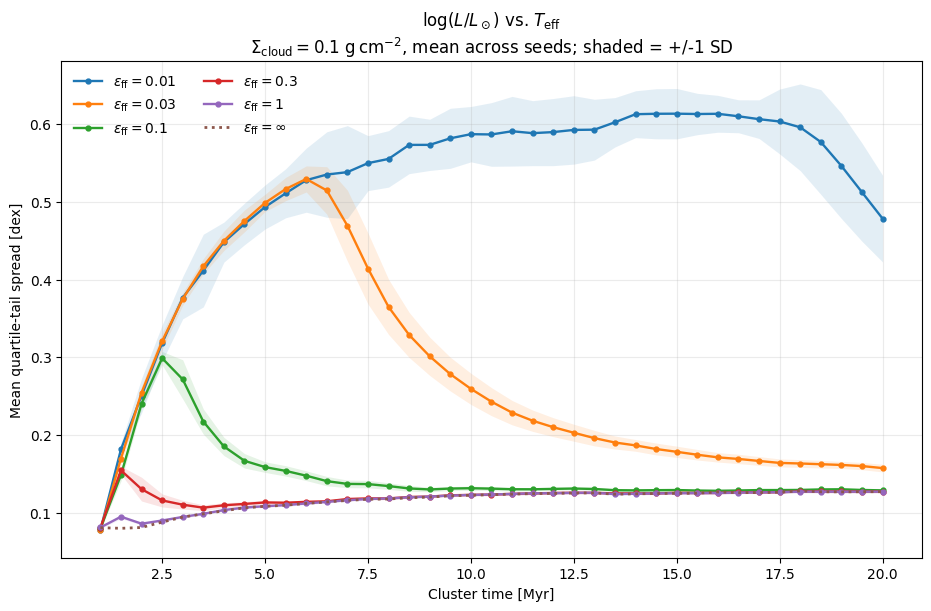

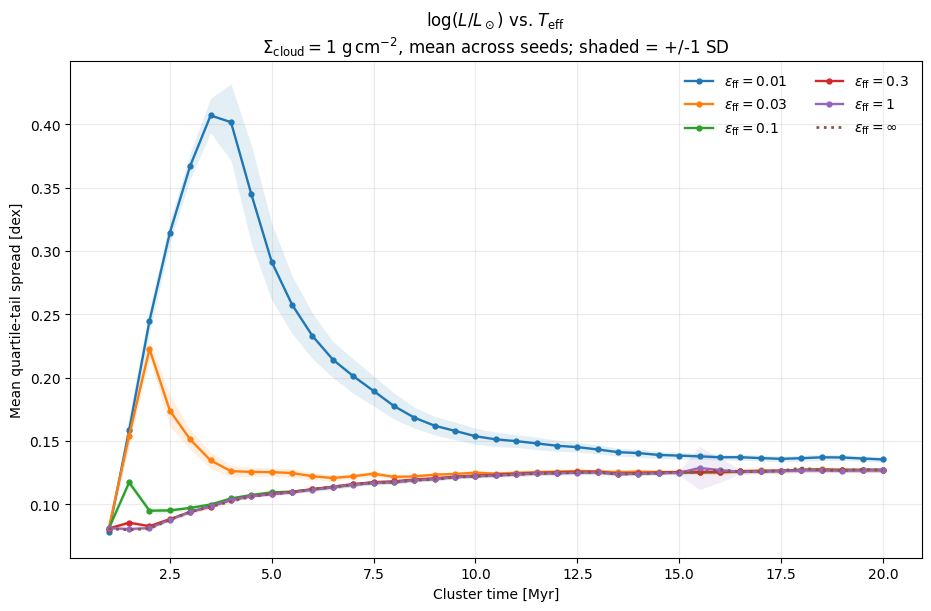

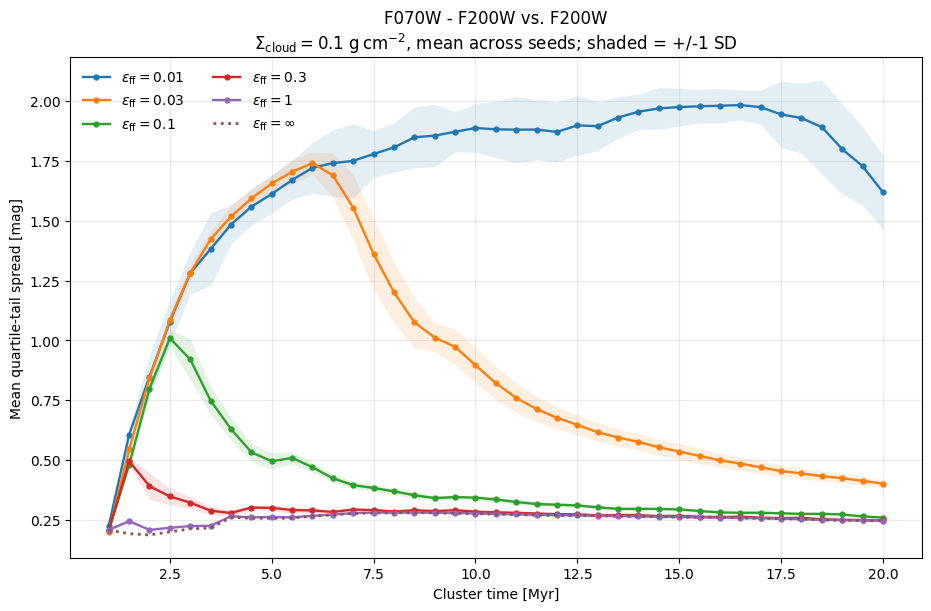

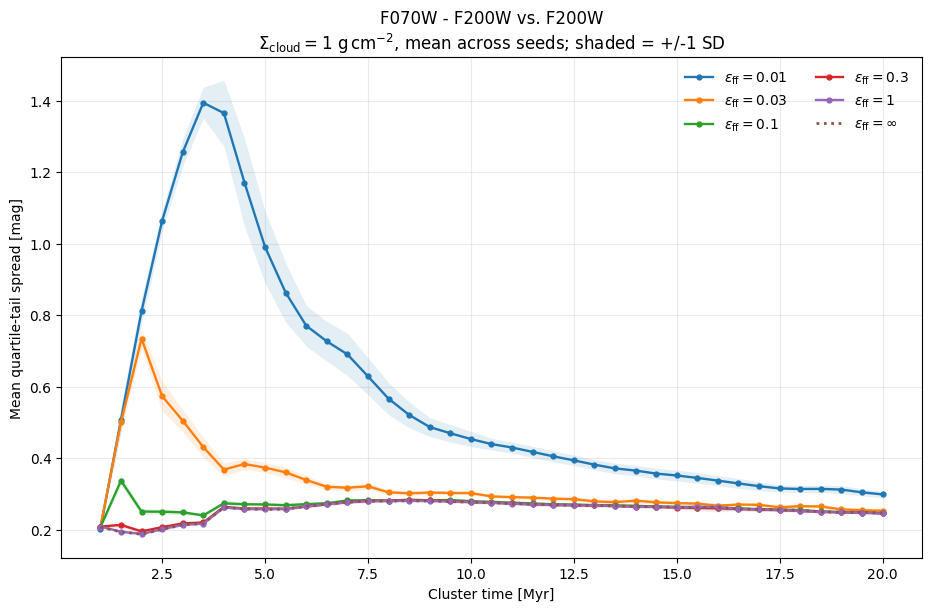

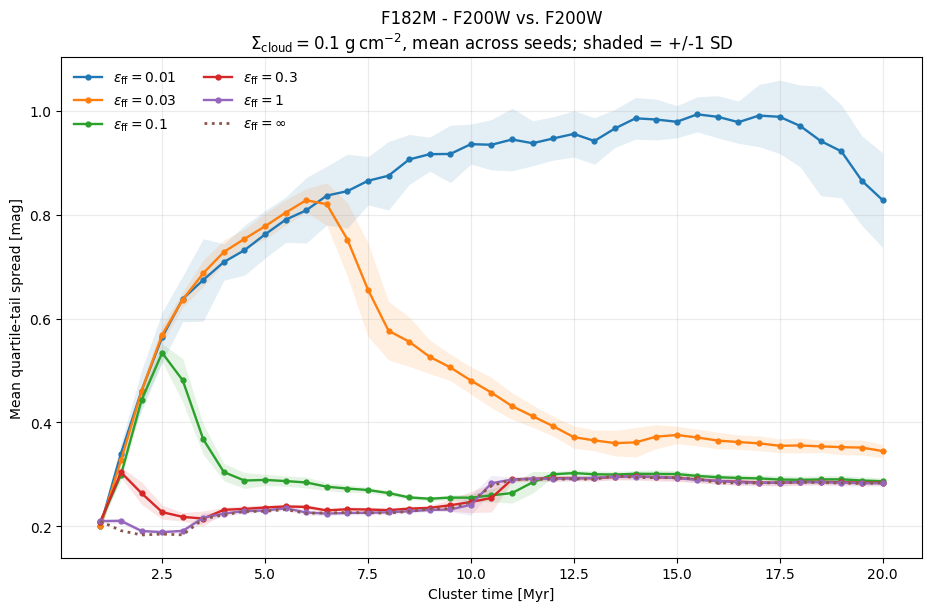

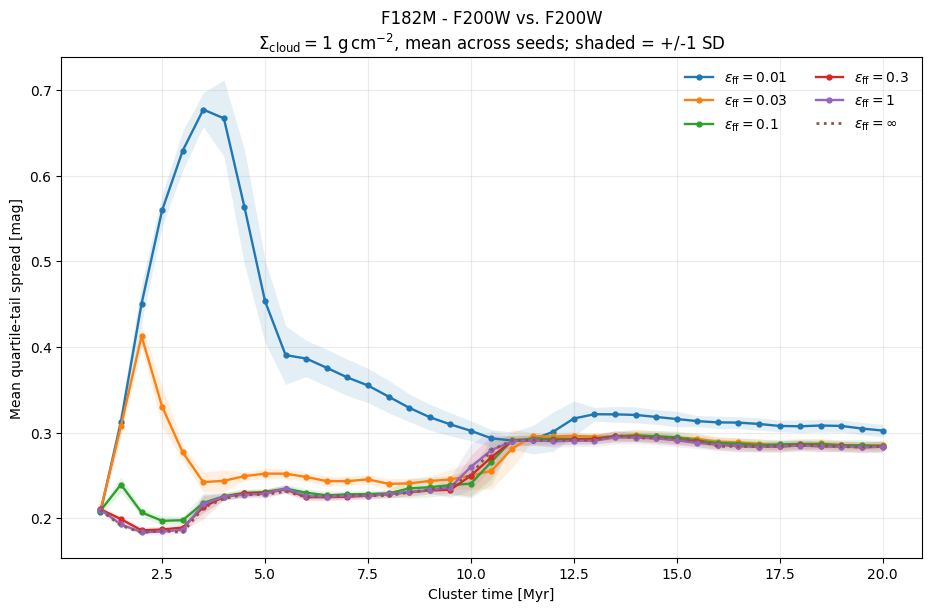

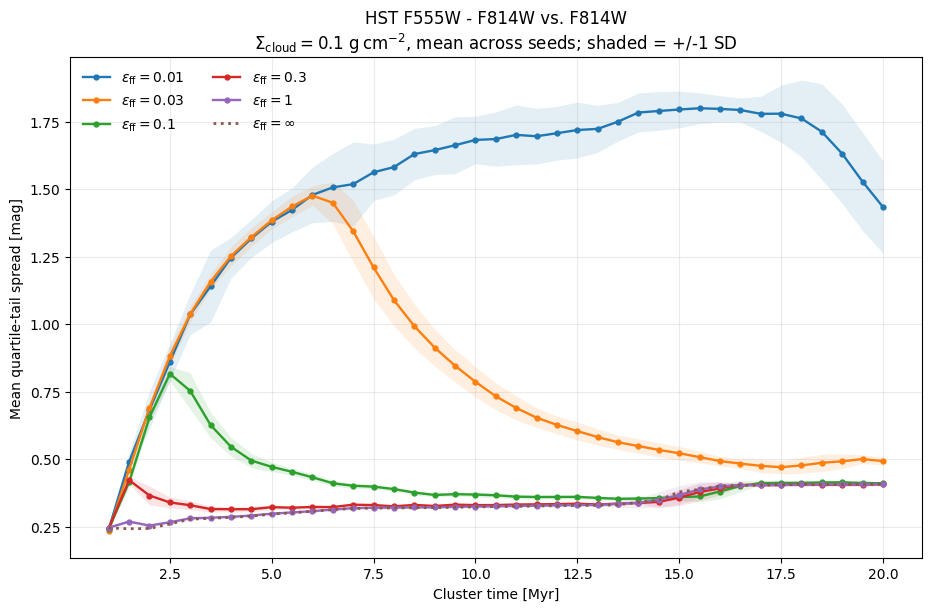

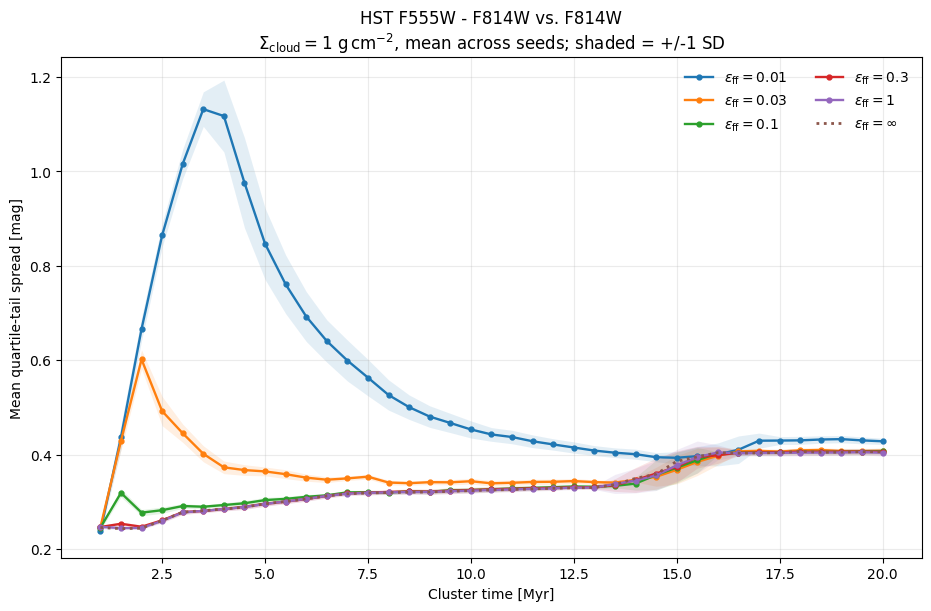

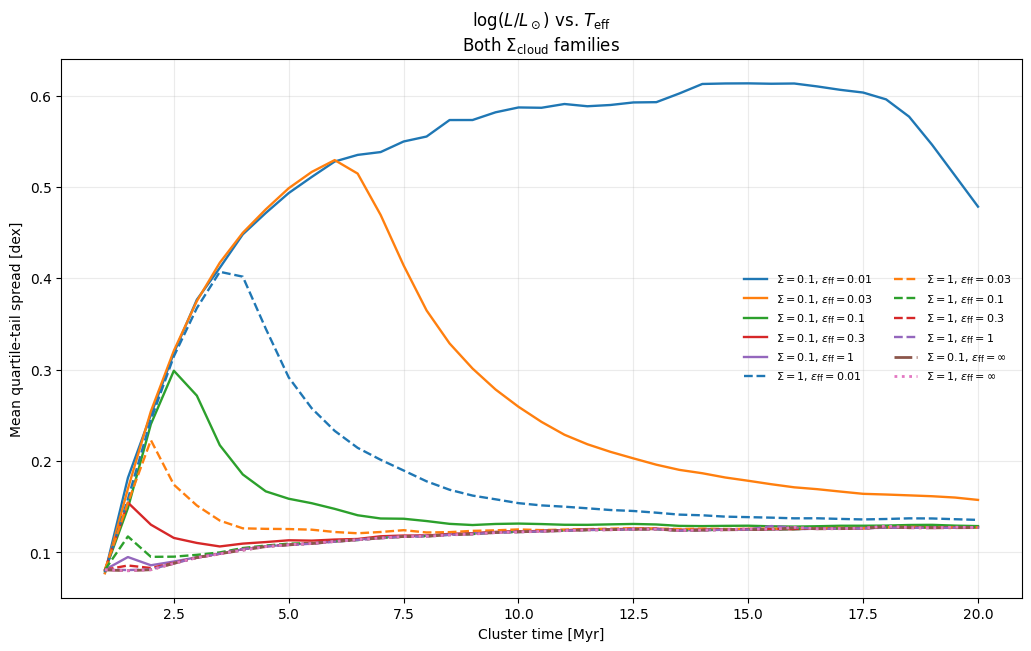

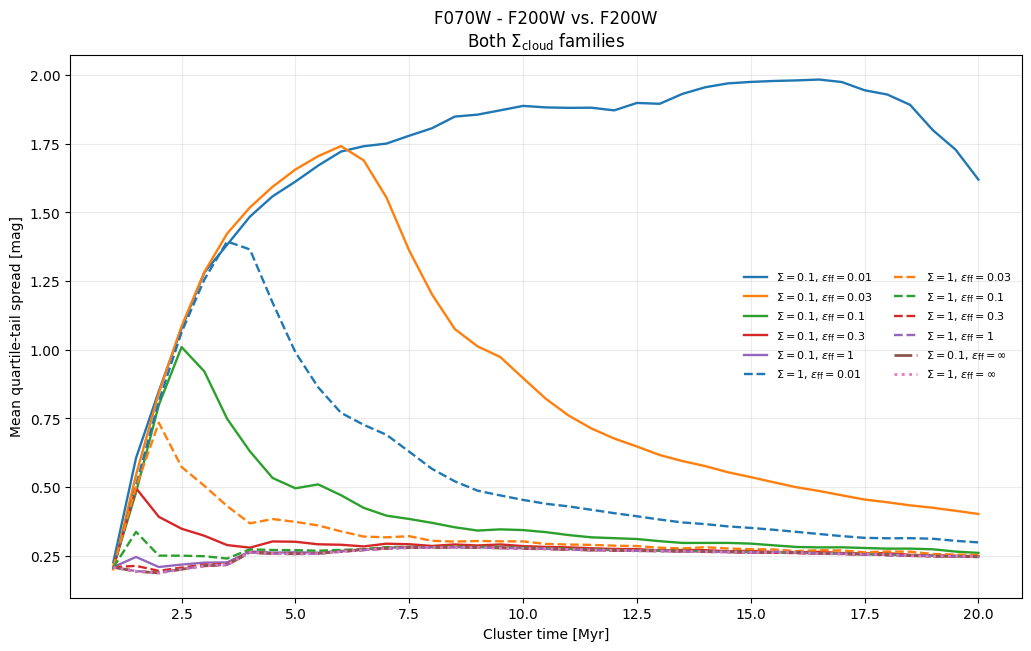

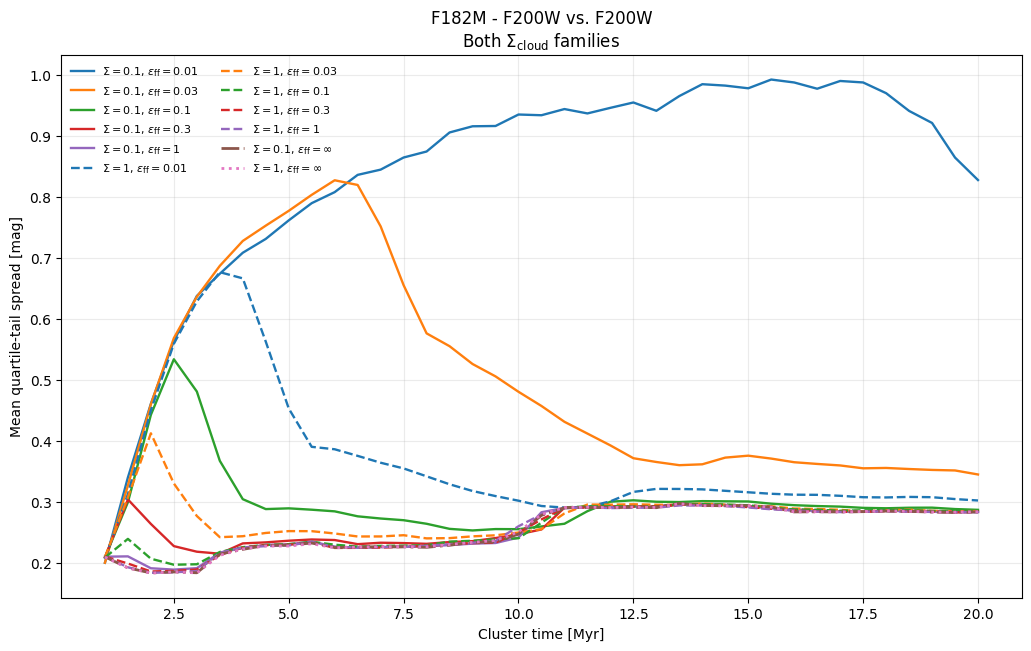

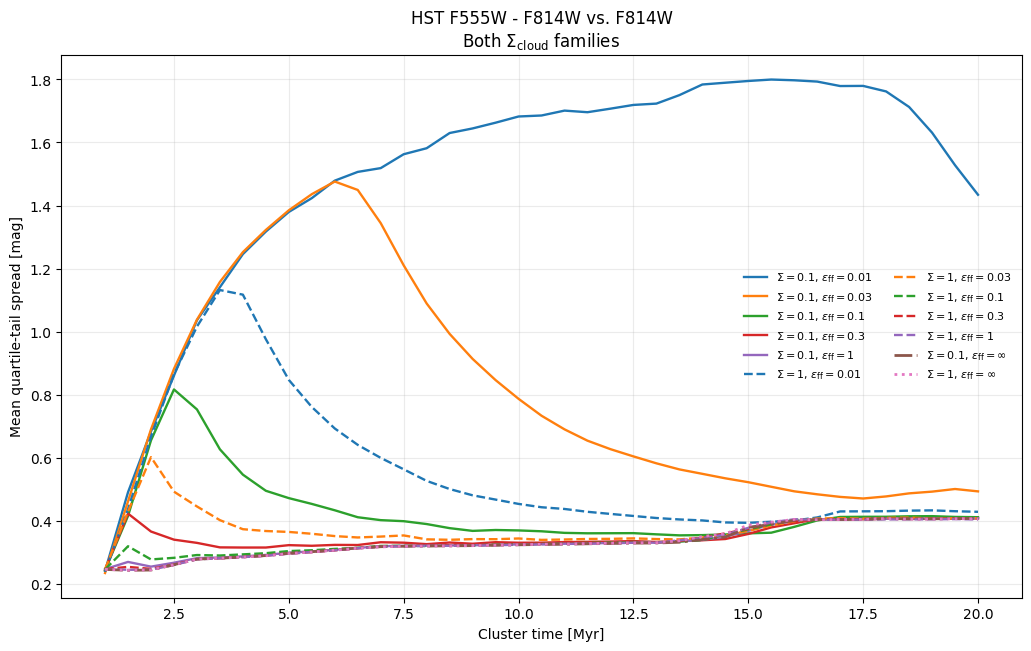

In [14]:
EFF_LABELS = {eff: rf'$\epsilon_{{\rm ff}}={eff:g}$' for eff in EFF_CONFIG}
SIGMA_LINESTYLES = {0.1: '-', 1.0: '--'}


def unit(d):
    return 'dex' if d.kind == 'hr' else 'mag'


# One plot per Sigma and diagram.
for d in DIAGRAMS:
    for sigma in sorted(finite_ens['sigma_cloud_g_cm2'].unique()):
        fig, ax = plt.subplots(figsize=(9.2, 6.0), constrained_layout=True)
        for eff in EFF_CONFIG:
            sub = finite_ens[
                (finite_ens['sigma_cloud_g_cm2'] == sigma)
                & (finite_ens['epsilon_ff'] == eff)
                & (finite_ens['diagram'] == d.key)
            ].sort_values('snapshot_time_myr')
            if sub.empty:
                continue
            line = ax.plot(
                sub['snapshot_time_myr'], sub['mean'],
                marker='o', ms=3.5, lw=1.7, label=EFF_LABELS[eff]
            )[0]
            # Shade +/- 1 SAMPLE standard deviation across seed realizations.
            # ddof=1 is used when the ensemble table is constructed above.
            # This band describes physical/stochastic seed-to-seed scatter; it is
            # deliberately NOT SEM, because SEM would describe uncertainty in the
            # estimated ensemble mean rather than the diversity of realizations.
            valid = (
                np.isfinite(sub['mean'])
                & np.isfinite(sub['std'])
            )
            lower = sub.loc[valid, 'mean'] - sub.loc[valid, 'std']
            upper = sub.loc[valid, 'mean'] + sub.loc[valid, 'std']
            ax.fill_between(
                sub.loc[valid, 'snapshot_time_myr'],
                lower,
                upper,
                alpha=0.12, color=line.get_color(), linewidth=0,
            )
        base = inst_sigma[
            (inst_sigma['sigma_cloud_g_cm2'] == sigma)
            & (inst_sigma['diagram'] == d.key)
        ].sort_values('snapshot_time_myr')
        if not base.empty:
            ax.plot(
                base['snapshot_time_myr'], base['mean'],
                lw=2.0, ls=':', label=r'$\epsilon_{\rm ff}=\infty$'
            )
        ax.set_xlabel('Cluster time [Myr]')
        ax.set_ylabel(f'Mean quartile-tail spread [{unit(d)}]')
        ax.set_title(
            d.title + '\n'
            + rf'$\Sigma_{{\rm cloud}}={sigma:g}\ {{\rm g\,cm^{{-2}}}}$'
            + ', mean across seeds; shaded = +/-1 SD'
        )
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, ncol=2)
        finish_figure(fig, f'spread_by_eff_{sigma_tag(sigma)}_{d.key}.png')


# Both Sigma values on same plot.
for d in DIAGRAMS:
    fig, ax = plt.subplots(figsize=(10.2, 6.4), constrained_layout=True)
    eff_colors = {}
    sigmas = sorted(finite_ens['sigma_cloud_g_cm2'].unique())

    for sidx, sigma in enumerate(sigmas):
        ls = SIGMA_LINESTYLES.get(float(sigma), '-' if sidx == 0 else '--')
        for eff in EFF_CONFIG:
            sub = finite_ens[
                (finite_ens['sigma_cloud_g_cm2'] == sigma)
                & (finite_ens['epsilon_ff'] == eff)
                & (finite_ens['diagram'] == d.key)
            ].sort_values('snapshot_time_myr')
            if sub.empty:
                continue
            kwargs = {'color': eff_colors[eff]} if eff in eff_colors else {}
            line = ax.plot(
                sub['snapshot_time_myr'], sub['mean'],
                lw=1.7, ls=ls,
                label=rf'$\Sigma={sigma:g}$, {EFF_LABELS[eff]}',
                **kwargs,
            )[0]
            eff_colors.setdefault(eff, line.get_color())

    for sidx, sigma in enumerate(sigmas):
        base = inst_sigma[
            (inst_sigma['sigma_cloud_g_cm2'] == sigma)
            & (inst_sigma['diagram'] == d.key)
        ].sort_values('snapshot_time_myr')
        if base.empty:
            continue
        ax.plot(
            base['snapshot_time_myr'], base['mean'],
            lw=2.0, ls='-.' if sidx == 0 else ':',
            label=rf'$\Sigma={sigma:g}$, $\epsilon_{{\rm ff}}=\infty$',
        )

    ax.set_xlabel('Cluster time [Myr]')
    ax.set_ylabel(f'Mean quartile-tail spread [{unit(d)}]')
    ax.set_title(d.title + '\nBoth ' + r'$\Sigma_{\rm cloud}$' + ' families')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=2, fontsize=8)
    finish_figure(fig, f'spread_by_eff_both_sigma_{d.key}.png')

## Metadata / output manifest

In [15]:
metadata = {
    'simulation_base': str(SIMULATION_BASE),
    'sigma_dir_candidates': SIGMA_DIR_CANDIDATES,
    'epsilon_ff_directories': EFF_CONFIG,
    'n_discovered_simulations': int(len(df_inventory)),
    'temperature_selection': 'global 3000 <= Teff <= 3600 K',
    'reference_bin_age_myr': REFERENCE_BIN_AGE_MYR,
    'cmd_bin_definition': (
        '1 Myr color at 3000 K and 3600 K -> six equal-width fixed color bins'
    ),
    'hr_bin_definition': 'six fixed 100 K bins from 3000 to 3600 K',
    'minimum_stars_per_bin': MIN_STARS_PER_BIN,
    'instantaneous_definition': (
        'one matched instantaneous control for every Sigma/e_ff/seed realization'
    ),
    'instantaneous_sigma_baseline': (
        'seed-mean within each source e_ff, then equal-weight mean of source-e_ff means'
    ),
    'finite_ensemble_curve': 'arithmetic mean spread_metric across available seeds',
    'finite_ensemble_band': (
        'mean +/- 1 sample standard deviation across contributing seeds; '
        'sample SD uses ddof=1 and represents realization-to-realization scatter, '
        'not uncertainty on the ensemble mean'
    ),
    'saved_seed_statistics': (
        'n, mean, sample std (ddof=1), SEM, median, p16, p84, min, max; '
        'plots use mean +/- sample std'
    ),
    'analysis_times_myr': ANALYSIS_TIMES_MYR.tolist(),
    'filters': FILTER_OBSMODES,
    'diagrams': [asdict(d) for d in DIAGRAMS],
    'run_signature': RUN_SIGNATURE,
}
(OUTPUT_DIR / 'analysis_metadata.json').write_text(json.dumps(metadata, indent=2))

manifest = pd.DataFrame([
    ('simulation_inventory.csv', 'Discovered simulation paths.'),
    ('all_realization_spread_summary.csv', 'Every finite and matched instantaneous spread result.'),
    ('all_realization_spread_bins.csv', 'Every per-bin measurement.'),
    ('all_realization_interpolation_accounting.csv', 'Interpolation accounting/failures.'),
    ('finite_spread_ensemble_statistics.csv', 'Finite mean/sample-SD/SEM/median/p16/p84/min/max across seeds; figures use mean +/- SD.'),
    ('instantaneous_spread_statistics_by_source_eff.csv', 'Instantaneous ensembles by source e_ff.'),
    ('instantaneous_spread_sigma_baseline.csv', 'Hierarchical instantaneous baseline per Sigma.'),
    ('matched_finite_instantaneous_spread.csv', 'Exact paired finite/instantaneous ratios and excesses.'),
    ('matched_normalized_spread_ensemble_statistics.csv', 'Seed statistics of matched S/S_inf.'),
    ('matched_excess_spread_ensemble_statistics.csv', 'Seed statistics of matched S-S_inf.'),
    ('finite_metric_coverage.csv', 'Number of contributing seeds / valid-bin coverage.'),
    ('static_1myr_bin_definitions.csv', 'Frozen measurement-bin geometry.'),
    ('instantaneous_age_spread_validation.csv', 'Instantaneous Delta-t90 validation.'),
    ('analysis_metadata.json', 'Full analysis definition/configuration.'),
], columns=['filename', 'description'])
manifest.to_csv(OUTPUT_DIR / 'output_manifest.csv', index=False)

print('=' * 80)
print('Analysis complete')
print('Outputs:', OUTPUT_DIR.resolve())
print('Cache:', CACHE_DIR.resolve())
print('Primary reusable table:', ALL_SUMMARY.resolve())

Analysis complete
Outputs: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis/all_seeds_all_sigma_all_eff_spread_std_outputs
Cache: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis/all_seeds_all_sigma_all_eff_analysis_cache
Primary reusable table: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis/all_seeds_all_sigma_all_eff_spread_std_outputs/all_realization_spread_summary.csv
